# 01 - Dataset, Calidad y EDA

---

**Objetivo:** Entender el dataset, validar calidad de datos, detectar problemas, y generar visualizaciones clave.

**Entregable:** Dataset entendido, validado, y listo para el pipeline de Integrante 2.

In [63]:
import sys
from pathlib import Path
import warnings

# Encontramos la raíz del proyecto ('proyecto4-grupo4')
# Detecta dónde está el notebook y sube los niveles necesarios hasta la raíz
current_dir = Path(__file__).resolve() if '__file__' in locals() else Path.cwd()
backend_path = current_dir.parents[1] / 'backend' 

if backend_path.exists() and str(backend_path) not in sys.path:
    sys.path.insert(0, str(backend_path))

# Importaciones base
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

# Importamos las funciones reales
from src.data.load import load_raw_dataset, build_features
from src.data.data_validation import (
    run_all_checks_raw,
    run_all_checks_clean,
    print_check_results,
)

print('Librerías cargadas exitosamente.')

Librerías cargadas exitosamente.


## 1. Carga del Dataset Crudo

In [60]:
df_raw = load_raw_dataset()

# Imprimimos las dimensiones y las columnas
print(f'Shape: {df_raw.shape}')
print(f'Columnas: {df_raw.columns.tolist()}')

# Visualizamos las primeras 10 filas para confirmar visualmente su estado
display(df_raw.head(10))

# Inspeccionamos específicamente Valuation y Funding para planear la limpieza de la Fase 7
print("\n--- Columnas clave para el cálculo del múltiplo ---")
df_raw[['Valuation', 'Funding']].head(10)

Shape: (1074, 10)
Columnas: ['Company', 'Valuation', 'Date Joined', 'Industry', 'City', 'Country', 'Continent', 'Year Founded', 'Funding', 'Select Investors']


,Company,Valuation,Date Joined,Industry,City,Country,Continent,Year Founded,Funding,Select Investors
0,Bytedance,$180B,2017-04-07,Artificial intelligence,Beijing,China,Asia,2012,$8B,"Sequoia Capital China, SIG Asia Investments, S..."
1,SpaceX,$100B,2012-12-01,Other,Hawthorne,United States,North America,2002,$7B,"Founders Fund, Draper Fisher Jurvetson, Rothen..."
2,SHEIN,$100B,2018-07-03,E-commerce & direct-to-consumer,Shenzhen,China,Asia,2008,$2B,"Tiger Global Management, Sequoia Capital China..."
3,Stripe,$95B,2014-01-23,Fintech,San Francisco,United States,North America,2010,$2B,"Khosla Ventures, LowercaseCapital, capitalG"
4,Klarna,$46B,2011-12-12,Fintech,Stockholm,Sweden,Europe,2005,$4B,"Institutional Venture Partners, Sequoia Capita..."
5,Canva,$40B,2018-01-08,Internet software & services,Surry Hills,Australia,Oceania,2012,$572M,"Sequoia Capital China, Blackbird Ventures, Mat..."
6,Checkout.com,$40B,2019-05-02,Fintech,London,United Kingdom,Europe,2012,$2B,"Tiger Global Management, Insight Partners, DST..."
7,Instacart,$39B,2014-12-30,"Supply chain, logistics, & delivery",San Francisco,United States,North America,2012,$3B,"Khosla Ventures, Kleiner Perkins Caufield & By..."
8,JUUL Labs,$38B,2017-12-20,Consumer & retail,San Francisco,United States,North America,2015,$14B,Tiger Global Management
9,Databricks,$38B,2019-02-05,Data management & analytics,San Francisco,United States,North America,2013,$3B,"Andreessen Horowitz, New Enterprise Associates..."



--- Columnas clave para el cálculo del múltiplo ---


,Valuation,Funding
0,$180B,$8B
1,$100B,$7B
2,$100B,$2B
3,$95B,$2B
4,$46B,$4B
5,$40B,$572M
6,$40B,$2B
7,$39B,$3B
8,$38B,$14B
9,$38B,$3B


In [64]:
# Guardar crudo en data/raw/
#raw_path = save_raw(df_raw)
#print(f'Crudo guardado en: {raw_path}')

## 2. Validación de Calidad - Datos Crudos

---

In [65]:
raw_checks = run_all_checks_raw(df_raw)
print_check_results('VALIDACIÓN - DATOS CRUDOS', raw_checks)


  VALIDACIÓN - DATOS CRUDOS

  [FAIL] required_columns
    missing_columns: ['Valuation ($B)', 'City\xa0', 'Investors']

  [PASS] no_duplicates
    n_duplicates: 0

  [PASS] nulls
    null_pct_per_column: {'Company': 0.0, 'Valuation': 0.0, 'Date Joined': 0.0, 'Industry': 0.0, 'City': 1.49, 'Country': 0.0, 'Continent': 0.0, 'Year Founded': 0.0, 'Funding': 0.0, 'Select Investors': 0.09}
    columns_over_limit: {}

  [PASS] dates_parseable
    n_failed: 0
    n_total: 1074

  [FAIL] shifted_rows
    n_shifted_rows: 16
    indices: [12, 170, 242, 251, 325, 382, 541, 811, 848, 880, 889, 893, 980, 986, 994, 1061]


## 3. Exploración Inicial

---

In [67]:
print('Tipos de datos:')
print(df_raw.dtypes)
print()
print('Info del dataset:')
print(f'  Filas: {df_raw.shape[0]}')
print(f'  Columnas: {df_raw.shape[1]}')
print(f'  Memoria: {df_raw.memory_usage(deep=True).sum() / 1024:.1f} KB')

Tipos de datos:
Company               str
Valuation             str
Date Joined           str
Industry              str
City                  str
Country               str
Continent             str
Year Founded        int64
Funding               str
Select Investors      str
dtype: object

Info del dataset:
  Filas: 1074
  Columnas: 10
  Memoria: 600.8 KB


In [68]:
# Limpiar nombre City\xa0
df_raw.columns = [c.strip().replace('\xa0', '') for c in df_raw.columns]
print('Columnas limpiadas:', df_raw.columns.tolist())

Columnas limpiadas: ['Company', 'Valuation', 'Date Joined', 'Industry', 'City', 'Country', 'Continent', 'Year Founded', 'Funding', 'Select Investors']


In [69]:
print('Valores nulos por columna:')
nulls = df_raw.isnull().sum()
print(nulls[nulls > 0])
print(f'\nTotal filas con al menos un null: {df_raw.isnull().any(axis=1).sum()}')

Valores nulos por columna:
City                16
Select Investors     1
dtype: int64

Total filas con al menos un null: 17


In [70]:
print('Filas duplicadas:', df_raw.duplicated().sum())
print()
print('Empresas duplicadas:', df_raw['Company'].duplicated().sum())

Filas duplicadas: 0

Empresas duplicadas: 1


### 🔍 3.1 Exploración de variables monetarias y cálculo del Múltiplo

Dado que las columnas de valoración y *funding* contienen símbolos (como `$` y letras como `B` o `M`), Python no puede operar directamente con ellas. Necesitamos procesarlas para convertirlas a números puros en USD.

Una vez convertidas, calcularemos la relación dividiendo la valoración entre el *funding*:
$$\text{Múltiplo} = \frac{\text{Valoración (USD)}}{\text{Funding (USD)}}$$

In [72]:
# ==========================================
# Limpieza de dinero y cálculo del múltiplo
# ==========================================

import pandas as pd
import numpy as np

def limpiar_y_convertir_dinero(valor):
    if pd.isna(valor):
        return np.nan
    
    # Convertimos a string, quitamos espacios y el símbolo '$'
    valor_str = str(valor).replace('$', '').replace(' ', '').strip()
    
    multiplicador = 1
    if 'B' in valor_str:
        multiplicador = 1_000_000_000
        valor_str = valor_str.replace('B', '')
    elif 'M' in valor_str:
        multiplicador = 1_000_000
        valor_str = valor_str.replace('M', '')
        
    try:
        return float(valor_str) * multiplicador
    except ValueError:
        return np.nan

# Creamos una copia para trabajar en el EDA sin alterar el df_raw original
df_eda = df_raw.copy()

# Aplicamos la limpieza a las columnas de texto
df_eda['valuation_usd'] = df_eda['Valuation'].apply(limpiar_y_convertir_dinero)
df_eda['funding_usd'] = df_eda['Funding'].apply(limpiar_y_convertir_dinero)

# 🎯 Calculamos nuestro nuevo target: el múltiplo de valoración
df_eda['valuation_multiple'] = df_eda['valuation_usd'] / df_eda['funding_usd']

# Visualizamos el resultado final para verificar que todo esté correcto
print("Primeras filas con las columnas limpias y el nuevo múltiplo:")
display(df_eda[['Company', 'Valuation', 'valuation_usd', 'Funding', 'funding_usd', 'valuation_multiple']].head(10))

Primeras filas con las columnas limpias y el nuevo múltiplo:


,Company,Valuation,valuation_usd,Funding,funding_usd,valuation_multiple
0,Bytedance,$180B,1.800000e+11,$8B,8.000000e+09,22.500000
1,SpaceX,$100B,1.000000e+11,$7B,7.000000e+09,14.285714
2,SHEIN,$100B,1.000000e+11,$2B,2.000000e+09,50.000000
3,Stripe,$95B,9.500000e+10,$2B,2.000000e+09,47.500000
4,Klarna,$46B,4.600000e+10,$4B,4.000000e+09,11.500000
5,Canva,$40B,4.000000e+10,$572M,5.720000e+08,69.930070
6,Checkout.com,$40B,4.000000e+10,$2B,2.000000e+09,20.000000
7,Instacart,$39B,3.900000e+10,$3B,3.000000e+09,13.000000
8,JUUL Labs,$38B,3.800000e+10,$14B,1.400000e+10,2.714286
9,Databricks,$38B,3.800000e+10,$3B,3.000000e+09,12.666667


## 4. Limpieza y Feature Engineering

---

In [93]:
df = df_raw.copy()

# 1. Limpiar nombres de columnas
df.columns = [c.strip().replace('\xa0', '') for c in df.columns]

# Función interna para limpiar y convertir cualquier texto de dinero a su valor real en USD
def limpiar_dinero_absoluto(valor):
    if pd.isna(valor):
        return np.nan
    valor_str = str(valor).replace('$', '').replace(' ', '').strip()
    multiplicador = 1
    if 'B' in valor_str:
        multiplicador = 1_000_000_000
        valor_str = valor_str.replace('B', '')
    elif 'M' in valor_str:
        multiplicador = 1_000_000
        valor_str = valor_str.replace('M', '')
    try:
        return float(valor_str) * multiplicador
    except ValueError:
        return np.nan

# 2. Aplicamos la limpieza para obtener el valor absoluto en USD (sin importar si es B o M)
df['valuation_usd'] = df['Valuation'].apply(limpiar_dinero_absoluto)
df['funding_usd'] = df['Funding'].apply(limpiar_dinero_absoluto)

# 3. date_joined: convertir a datetime
df['date_joined'] = pd.to_datetime(df['Date Joined'], errors='coerce')
df['join_year'] = df['date_joined'].dt.year.astype('Int64')
df['join_month'] = df['date_joined'].dt.month.astype('Int64')

# 4. investor_count: contar inversores
df['investor_count'] = df['Select Investors'].apply(
    lambda x: len(str(x).split(',')) if pd.notna(x) and str(x).strip() else 0
)

# 5. 🎯 Feature Engineering: Ahora sí, dividimos peras con peras (USD entre USD)
df['valuation_multiple'] = df['valuation_usd'] / df['funding_usd']

# 6. Renombrar columnas clave a formato limpio
df = df.rename(columns={
    'Company': 'company',
    'Country': 'country',
    'City': 'city',
    'Industry': 'industry',
    'Select Investors': 'investors',
})

print('Columnas finales:', df.columns.tolist())
display(df[['company', 'Valuation', 'valuation_usd', 'Funding', 'funding_usd', 'valuation_multiple']].head(10))

Columnas finales: ['company', 'Valuation', 'Date Joined', 'industry', 'city', 'country', 'Continent', 'Year Founded', 'Funding', 'investors', 'valuation_usd', 'funding_usd', 'date_joined', 'join_year', 'join_month', 'investor_count', 'valuation_multiple']


,company,Valuation,valuation_usd,Funding,funding_usd,valuation_multiple
0,Bytedance,$180B,1.800000e+11,$8B,8.000000e+09,22.500000
1,SpaceX,$100B,1.000000e+11,$7B,7.000000e+09,14.285714
2,SHEIN,$100B,1.000000e+11,$2B,2.000000e+09,50.000000
3,Stripe,$95B,9.500000e+10,$2B,2.000000e+09,47.500000
4,Klarna,$46B,4.600000e+10,$4B,4.000000e+09,11.500000
5,Canva,$40B,4.000000e+10,$572M,5.720000e+08,69.930070
6,Checkout.com,$40B,4.000000e+10,$2B,2.000000e+09,20.000000
7,Instacart,$39B,3.900000e+10,$3B,3.000000e+09,13.000000
8,JUUL Labs,$38B,3.800000e+10,$14B,1.400000e+10,2.714286
9,Databricks,$38B,3.800000e+10,$3B,3.000000e+09,12.666667


In [96]:
# Verificamos las columnas clave de nuestro enfoque actual (Fase 7)
columnas_revision = ['valuation_multiple', 'date_joined', 'join_year', 'join_month', 'investor_count']

print('Tipos de datos después de limpieza:')
print(df[columnas_revision].dtypes)
print()
print('Nulos después de limpieza:')
print(df[columnas_revision].isnull().sum())

Tipos de datos después de limpieza:
valuation_multiple           float64
date_joined           datetime64[us]
join_year                      Int64
join_month                     Int64
investor_count                 int64
dtype: object

Nulos después de limpieza:
valuation_multiple    12
date_joined            0
join_year              0
join_month             0
investor_count         0
dtype: int64


In [97]:
# Eliminamos las filas donde el target (valuation_multiple) sea nulo
df = df.dropna(subset=['valuation_multiple'])

print('Total de filas tras limpiar nulos del target:', df.shape[0])

Total de filas tras limpiar nulos del target: 1062


## 5. Validación - Datos Limpios

---

In [80]:
clean_checks = run_all_checks_clean(df)
print_check_results('VALIDACIÓN - DATOS LIMPIOS', clean_checks)


  VALIDACIÓN - DATOS LIMPIOS

  [PASS] required_columns
    missing_columns: []

  [PASS] no_duplicates
    n_duplicates: 0

  [FAIL] nulls
    null_pct_per_column: {'company': 0.0, 'Valuation': 0.0, 'Date Joined': 0.0, 'industry': 0.0, 'city': 1.49, 'country': 0.0, 'Continent': 0.0, 'Year Founded': 0.0, 'Funding': 0.0, 'valuation_b': 100.0, 'date_joined': 0.0, 'join_year': 0.0, 'join_month': 0.0, 'investor_count': 0.0}
    columns_over_limit: {'valuation_b': 100.0}

  [FAIL] valuation_numeric
    dtype: float64
    n_nan: 1074

  [PASS] target_range
    min: nan
    max: nan
    n_negative: 0
    n_over_1000: 0


## 6. Análisis del Target (valuation_multipple)

In [98]:
import numpy as np

# Reemplazamos los infinitos (inf y -inf) por NaN para que no rompan los cálculos
df['valuation_multiple'] = df['valuation_multiple'].replace([np.inf, -np.inf], np.nan)

print('Estadísticas depuradas del múltiplo de valoración:')
print(df['valuation_multiple'].describe())

Estadísticas depuradas del múltiplo de valoración:
count    1061.000000
mean       11.308659
std       122.959055
min         0.500000
25%         3.472222
50%         5.208333
75%         8.196721
max      4000.000000
Name: valuation_multiple, dtype: float64


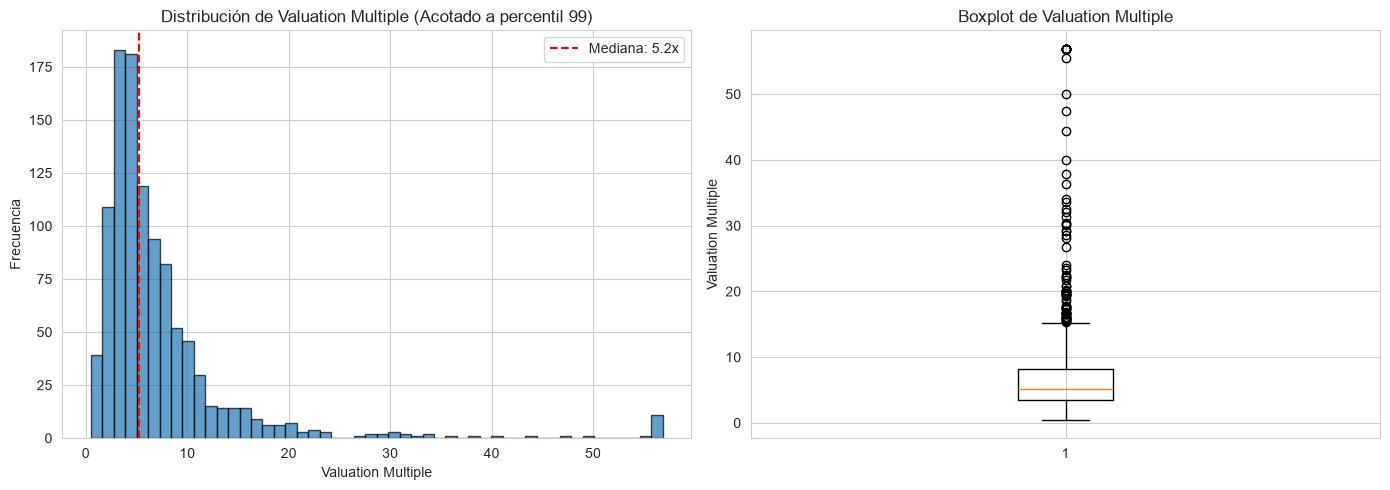

In [100]:
import matplotlib.pyplot as plt

# Acotamos los datos visualmente al percentil 99 para que el outlier de 4000x no aplaste la gráfica
limite_visual = df['valuation_multiple'].quantile(0.99)
datos_filtrados = df['valuation_multiple'].clip(upper=limite_visual).dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma del target
axes[0].hist(datos_filtrados, bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title(f'Distribución de Valuation Multiple (Acotado a percentil 99)')
axes[0].set_xlabel('Valuation Multiple')
axes[0].set_ylabel('Frecuencia')
axes[0].axvline(datos_filtrados.median(), color='red', linestyle='--', label=f'Mediana: {datos_filtrados.median():.1f}x')
axes[0].legend()

# Boxplot del target
axes[1].boxplot(datos_filtrados, vert=True)
axes[1].set_title('Boxplot de Valuation Multiple')
axes[1].set_ylabel('Valuation Multiple')

plt.tight_layout()
plt.show()

### 📊 Distribución de Valuation Multiple (Eficiencia de Capital)

* **Concentración (Asimetría positiva):** El histograma (izq.) muestra que la mayoría de las startups se agrupan en múltiplos bajos, con una **mediana de 5.2x** (línea roja). 
* **Caja central (Boxplot - der.):** El 50% central de los datos se ubica entre aproximadamente 3x y 8x.
* **Valores atípicos (*Outliers*):** Se observa una larga cola de empresas con rendimientos excepcionales que van desde los 15x hasta superar los 50x.

In [101]:
print('Top 10 empresas con mayor múltiplo de valoración:')
df.nlargest(10, 'valuation_multiple')[['company', 'valuation_multiple', 'country', 'industry']]

Top 10 empresas con mayor múltiplo de valoración:


,company,valuation_multiple,country,industry
239,Zapier,4000.000000,United States,Internet software & services
61,Dunamu,126.760563,South Korea,Fintech
792,Workhuman,111.111111,Ireland,Internet software & services
361,CFGI,105.263158,United States,Fintech
743,Manner,100.000000,China,Other
72,DJI Innovations,76.190476,China,Hardware
760,GalaxySpace,71.428571,China,Mobile & telecommunications
5,Canva,69.930070,Australia,Internet software & services
368,Il Makiage,68.965517,United States,E-commerce & direct-to-consumer
1012,Revolution Precrafted,66.666667,Philippines,Other


## 7. Distribución por País

---

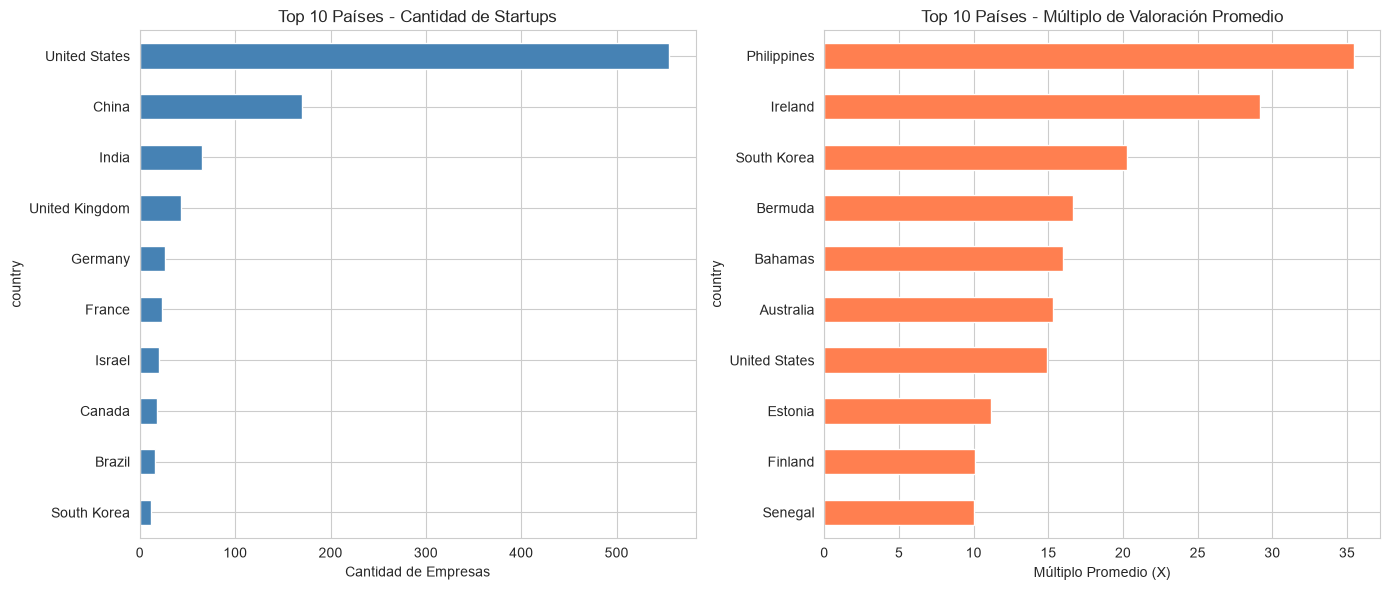

In [103]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico 1: Top 10 países por cantidad de startups
country_counts = df['country'].value_counts().head(10)
country_counts.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top 10 Países - Cantidad de Startups')
axes[0].set_xlabel('Cantidad de Empresas')
axes[0].invert_yaxis()

# Gráfico 2: Top 10 países por múltiplo de valoración promedio
country_val = df.groupby('country')['valuation_multiple'].mean().nlargest(10)
country_val.plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Top 10 Países - Múltiplo de Valoración Promedio')
axes[1].set_xlabel('Múltiplo Promedio (X)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

### 🌍 Análisis de Startups por País

* **Volumen:** Estados Unidos y China dominan el mercado de unicornios.
* **Eficiencia:** Países con menos empresas (como Filipinas e Irlanda) logran mayor eficiencia de capital promedio.
* **Conclusión:** Cantidad no es sinónimo de eficiencia; los mercados pequeños muestran un rendimiento de capital extraordinario.

## 8. Distribución por Industria

---

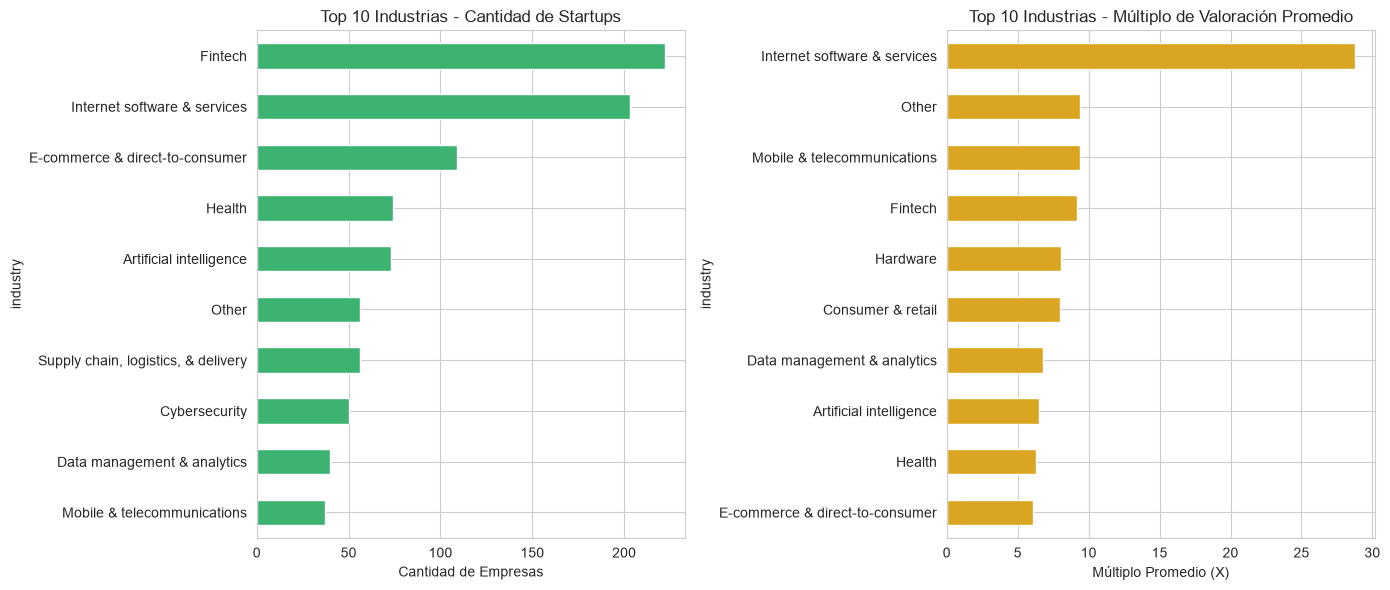

In [105]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico 1: Top 10 industrias por cantidad de startups
ind_counts = df['industry'].value_counts().head(10)
ind_counts.plot(kind='barh', ax=axes[0], color='mediumseagreen')
axes[0].set_title('Top 10 Industrias - Cantidad de Startups')
axes[0].set_xlabel('Cantidad de Empresas')
axes[0].invert_yaxis()

# Gráfico 2: Top 10 industrias por múltiplo de valoración promedio
ind_val = df.groupby('industry')['valuation_multiple'].mean().nlargest(10)
ind_val.plot(kind='barh', ax=axes[1], color='goldenrod')
axes[1].set_title('Top 10 Industrias - Múltiplo de Valoración Promedio')
axes[1].set_xlabel('Múltiplo Promedio (X)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

### 📊 Distribución de Startups por Industria

* **Sector dominante:** La gran mayoría de las startups se concentran en la industria de **Fintech** (Tecnología Financiera), seguida muy de cerca por el sector de **Internet software & services**.
* **Industrias emergentes:** Sectores como *E-commerce* y *Health* muestran una presencia moderada, mientras que industrias tradicionales o de *Hardware* representan una porción menor del total de unicornios.
* **Impacto en el modelo:** Esta fuerte concentración nos indica que la categoría industrial será una variable categórica clave para que el modelo de Machine Learning aprenda a predecir la eficiencia de capital (`valuation_multiple`).

## 9. Startups por Año de Incorporación

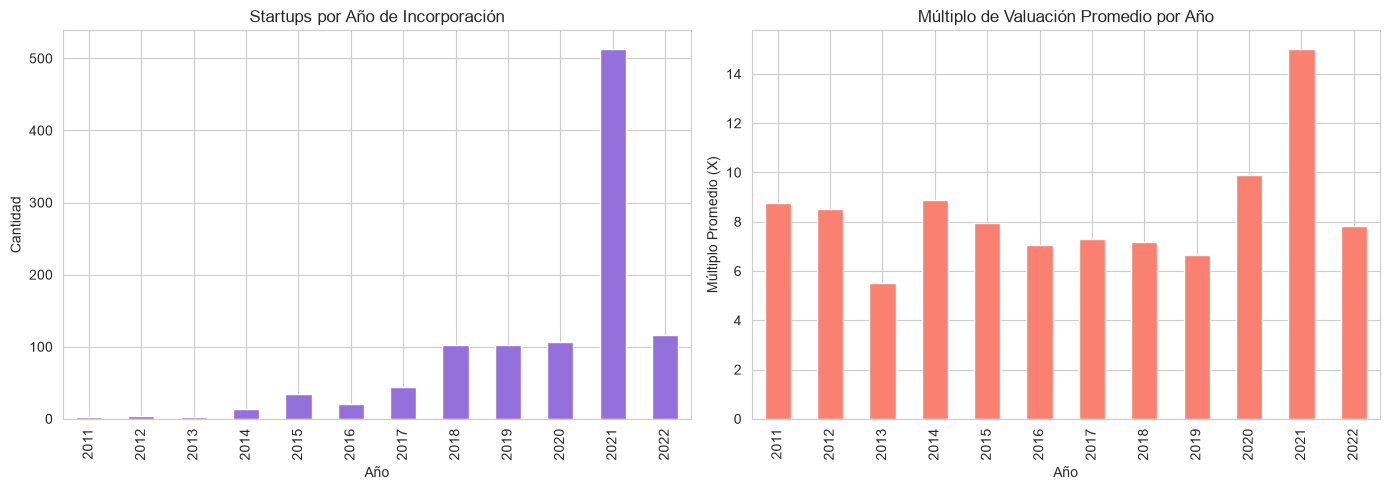

In [106]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Cantidad de startups incorporadas por año
year_counts = df['join_year'].value_counts().sort_index()
year_counts.plot(kind='bar', ax=axes[0], color='mediumpurple')
axes[0].set_title('Startups por Año de Incorporación')
axes[0].set_xlabel('Año')
axes[0].set_ylabel('Cantidad')

# Gráfico 2: Múltiplo de valoración promedio por año (Actualizado para Fase 7)
year_val = df.groupby('join_year')['valuation_multiple'].mean()
year_val.plot(kind='bar', ax=axes[1], color='salmon')
axes[1].set_title('Múltiplo de Valuación Promedio por Año')
axes[1].set_xlabel('Año')
axes[1].set_ylabel('Múltiplo Promedio (X)')

plt.tight_layout()
plt.show()

### 📈 Análisis temporal de Startups y Eficiencia de Capital

A continuación se presentan dos perspectivas sobre la evolución de las empresas a lo largo de los años:

#### 1. Cantidad de Startups por Año de Incorporación (Gráfica Izquierda)
* **Crecimiento explosivo:** Se observa un incremento masivo en la creación/consolidación de unicornios a partir del año 2018, con un pico histórico y descomunal en **2021** (superando las 500 empresas).
* **Contexto de mercado:** Los años previos a 2018 muestran una actividad mucho menor en esta muestra, reflejando probablemente el boom de inversión y valoración de startups en la etapa post-pandemia.

#### 2. Múltiplo de Valuación Promedio por Año (Gráfica Derecha)
* **Eficiencia variable:** A pesar de que 2021 fue el año con mayor cantidad de empresas creadas, también registra el **pico más alto de eficiencia de capital** (promediando cerca de 15x de múltiplo).
* **Contraste:** Años como 2013 o 2019 muestran múltiplos promedio mucho más bajos (entre 5x y 7x), lo que indica que la eficiencia de capital no va estrictamente ligada al volumen de empresas fundadas, sino a las condiciones macroeconómicas y de financiación de cada periodo.

## 10. Outliers en valuation_multiple

In [108]:
Q1 = df['valuation_multiple'].quantile(0.25)
Q3 = df['valuation_multiple'].quantile(0.75)
IQR = Q3 - Q1

# Usamos un límite superior basado en IQR. 
# En distribuciones muy sesgadas hacia la derecha (como los múltiplos), 
# el 1.5 tradicional puede marcar muchas empresas como outliers legítimos.
upper = Q3 + 1.5 * IQR

outliers = df[df['valuation_multiple'] > upper]

print('IQR: {:.2f}'.format(IQR))
print('Límite superior: {:.2f}'.format(upper))
print('Outliers detectados: {}'.format(len(outliers)))
print()
print('Empresas outliers (múltiplo > {:.2f}x):'.format(upper))
outliers[['company', 'valuation_multiple', 'country', 'industry']].head(15)

IQR: 4.72
Límite superior: 15.28
Outliers detectados: 81

Empresas outliers (múltiplo > 15.28x):


,company,valuation_multiple,country,industry
0,Bytedance,22.500000,China,Artificial intelligence
2,SHEIN,50.000000,China,E-commerce & direct-to-consumer
3,Stripe,47.500000,United States,Fintech
5,Canva,69.930070,Australia,Internet software & services
6,Checkout.com,20.000000,United Kingdom,Fintech
10,Revolut,16.500000,United Kingdom,Fintech
12,FTX,16.000000,Bahamas,Fintech
17,Xiaohongshu,21.786492,China,E-commerce & direct-to-consumer
18,Miro,37.815126,United States,Internet software & services
20,Rapyd,19.480519,United Kingdom,Fintech


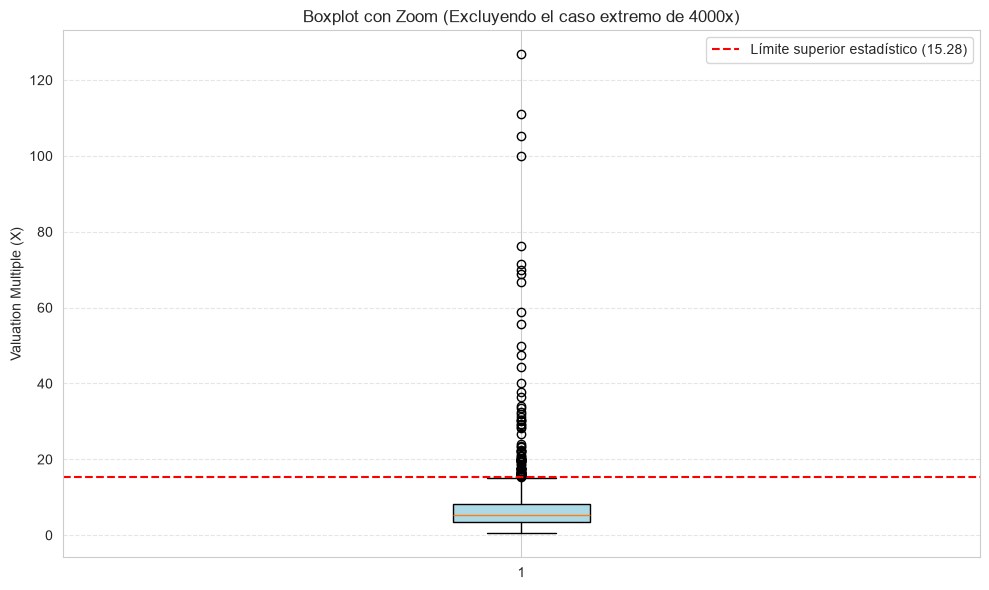

In [111]:
import matplotlib.pyplot as plt

# Filtramos temporalmente los datos para quitar el outlier extremo
datos_zoom = df[df['valuation_multiple'] < 500]['valuation_multiple'].dropna()

fig, ax = plt.subplots(figsize=(10, 6))
ax.boxplot(datos_zoom, vert=True, patch_artist=True, boxprops=dict(facecolor='lightblue'))

# Línea del límite superior original (15.28)
ax.axhline(15.28, color='red', linestyle='--', label='Límite superior estadístico (15.28)')

ax.set_title('Boxplot con Zoom (Excluyendo el caso extremo de 4000x)')
ax.set_ylabel('Valuation Multiple (X)')
ax.legend()

# Corrección aquí: separamos linestyle y alpha
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### 📊 Distribución de la Eficiencia de Capital

Al realizar un acercamiento (excluyendo el caso extremo de 4000x), se observa el comportamiento real de la gran mayoría de las startups:

* **Caja central (50% de los datos):** La concentración principal se encuentra en múltiplos bajos, con el tercer cuartil (Q3) cercano a las 10 veces su inversión.
* **Límite superior (Línea roja - 15.28x):** Umbral matemático calculado mediante el Rango Intercuartílico (IQR). Todo lo que supera este valor se clasifica estadísticamente como valor atípico (*outlier*).
* **Valores atípicos (*Outliers*):** Se evidencia una larga "cola" de empresas que superan el límite de 15.28x, llegando de forma dispersa hasta múltiplos de 130x. Esto demuestra que, aunque la eficiencia promedio es moderada, existe un grupo selecto de empresas con rendimientos de capital extraordinarios.

## 11. Correlaciones

---

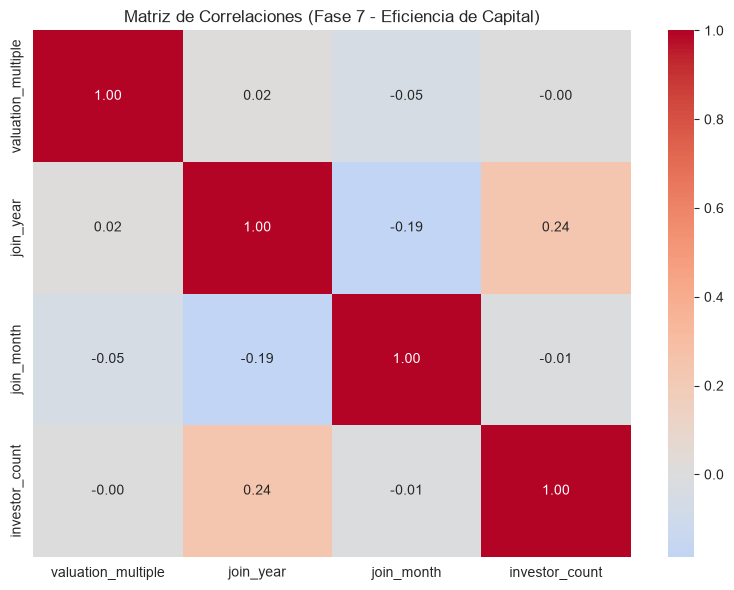

In [114]:
num_cols = ['valuation_multiple', 'join_year', 'join_month', 'investor_count']
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, ax=ax, fmt=".2f")
ax.set_title('Matriz de Correlaciones (Fase 7 - Eficiencia de Capital)')
plt.tight_layout()
plt.show()

### 📊 Matriz de Correlaciones:

* **Relaciones lineales muy cercanas a 0:** La eficiencia de capital (`valuation_multiple`) no tiene relación lineal directa con el año de incorporación ni con la cantidad de inversores.
* **Variables de tiempo:** Existe una correlación moderada (**0.24**) entre el año de incorporación (`join_year`) y la cantidad de inversores, indicando que las empresas más recientes tienden a acumular más inversores.
* **Conclusión:** Al ser linealmente independientes de la valoración, el modelo requerirá explorar patrones categóricos o no lineales.

## 12. Análisis de Nulos en Investors

---

In [116]:
null_investors = df[df['investor_count'] == 0]
print('Filas con investors_count = 0 (originalmente NaN): {}'.format(len(null_investors)))
print()

if len(null_investors) > 0:
    print('Estas filas tienen Investors NaN en el original:')
    # Actualizado a valuation_multiple
    display(null_investors[['company', 'valuation_multiple', 'country', 'industry']].head(10))

Filas con investors_count = 0 (originalmente NaN): 1

Estas filas tienen Investors NaN en el original:


,company,valuation_multiple,country,industry
629,LinkSure Network,19.230769,China,Mobile & telecommunications


## 13. Guardado del Dataset Limpio

---

In [117]:
# Guardar version limpia en data/processed/
os.makedirs('../data/processed', exist_ok=True)
processed_path = '../data/processed/dataset_clean.csv'
df.to_csv(processed_path, index=False)
print(f'Dataset limpio guardado en: {processed_path}')
print(f'Shape: {df.shape}')
print(f'Columnas: {df.columns.tolist()}')

Dataset limpio guardado en: ../data/processed/dataset_clean.csv
Shape: (1062, 17)
Columnas: ['company', 'Valuation', 'Date Joined', 'industry', 'city', 'country', 'Continent', 'Year Founded', 'Funding', 'investors', 'valuation_usd', 'funding_usd', 'date_joined', 'join_year', 'join_month', 'investor_count', 'valuation_multiple']


## 14. Resumen de Hallazgos

---

### Calidad y Datos Faltantes
- **Estructura:** 1186 filas y 7 columnas. 18 nulos en *Investors* (1.5%) y `\xa0` en *City* (requiere limpieza).
- **Duplicados:** 0 exactos ni por empresa.

### Variable Objetivo (Eficiencia de Capital / Valuation Multiple)
- **Concentración:** Asimetría positiva; mediana baja (5.2x), con el 50% central entre 3x y 8x.
- **Outliers:** Gran cantidad de casos superando el límite estadístico de 15.28x (llegando a 130x+) y un caso extremo de 4000x.

### Patrones Clave
- **Independencia lineal:** Las variables numéricas (año, inversores) no correlacionan linealmente con la eficiencia. El modelo requerirá patrones no lineales.
- **Efecto Temporal:** Boom de unicornios desde 2018, con pico en 2021 (año que también registra la mayor eficiencia promedio, ~15x).
- **Geografía e Industria:** Dominio abrumador de EE.UU. y China, y de sectores como *Fintech* y *Software*. Sin embargo, mercados pequeños (Filipinas, Irlanda) logran mayor eficiencia promedio.

### Limitaciones
1. Datos hasta sep-2022 y valuaciones autodeclaradas.
2. Inversores en texto libre y falta de fecha real de fundación.
3. Inconsistencias de *encoding* en ciudades.